In [59]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [42]:
data_dir = "banana dataset"

batch_size =16
img_height = 180
img_width = 180

In [43]:
print("Loading Data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='binary'
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)




Loading Data...
Found 7794 files belonging to 2 classes.
Using 6236 files for training.
Found 7794 files belonging to 2 classes.
Using 1558 files for validation.


In [26]:

inputs = keras.Input(shape=(img_height, img_width, 3))



# Rescaling
x = layers.Rescaling(1./255)(inputs)

# 2. CONVOLUTIONAL BASE (Simplified Depth)
# Block 1
x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 2
x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 3
x = layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 4 (Only one block of 512 filters now)
x = layers.Conv2D(512, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling2D()(x)

# 3. CLASSIFICATION HEAD (Heavy Dropout)
x = layers.Dropout(0.7)(x) # High dropout to prevent overfitting
outputs = layers.Dense(1, activation='sigmoid',
                       kernel_regularizer=regularizers.l2(0.01))(x)

model = keras.Model(inputs, outputs)

# 4. COMPILE (Lower Learning Rate)
# A lower LR reduces the "spiking" in validation loss
optimizer = tf.keras.optimizers.Adam(learning_rate=6e-6)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [27]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 180, 180, 64)      1792      
                                                                 
 batch_normalization_4 (Batc  (None, 180, 180, 64)     256       
 hNormalization)                                                 
                                                                 
 activation_4 (Activation)   (None, 180, 180, 64)      0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 90, 90, 64)       0         
 2D)                                                       

In [28]:
# 4. COMPILE
# ==========================================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# 5. TRAIN
# ==========================================================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

epochs = 50
print(f"\nStarting Training...")

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[early_stop, reduce_lr],
  batch_size=batch_size
)


Starting Training...
Epoch 1/50


390/390 [==============================] - 61s 71ms/step - loss: 6.3348 - accuracy: 0.7073 - val_loss: 6.1044 - val_accuracy: 0.5892 - lr: 1.0000e-05
Epoch 2/50
390/390 [==============================] - 23s 60ms/step - loss: 5.6685 - accuracy: 0.7957 - val_loss: 5.3534 - val_accuracy: 0.8235 - lr: 1.0000e-05
Epoch 3/50
390/390 [==============================] - 19s 49ms/step - loss: 5.1336 - accuracy: 0.8204 - val_loss: 4.8238 - val_accuracy: 0.8793 - lr: 1.0000e-05
Epoch 4/50
390/390 [==============================] - 19s 49ms/step - loss: 4.6805 - accuracy: 0.8422 - val_loss: 4.4877 - val_accuracy: 0.8261 - lr: 1.0000e-05
Epoch 5/50
390/390 [==============================] - 22s 56ms/step - loss: 4.2795 - accuracy: 0.8486 - val_loss: 4.0825 - val_accuracy: 0.8614 - lr: 1.0000e-05
Epoch 6/50
390/390 [==============================] - 25s 63ms/step - loss: 3.9433 - accuracy: 0.8619 - val_loss: 3.7217 - val_accuracy: 0.8999 - lr: 1.0000e-05
Epoch 7/50
390/390 [=========================


Final Evaluation:
98/98 [==============================] - 1s 13ms/step - loss: 1.4504 - accuracy: 0.9544
Final Validation Accuracy: 95.44%


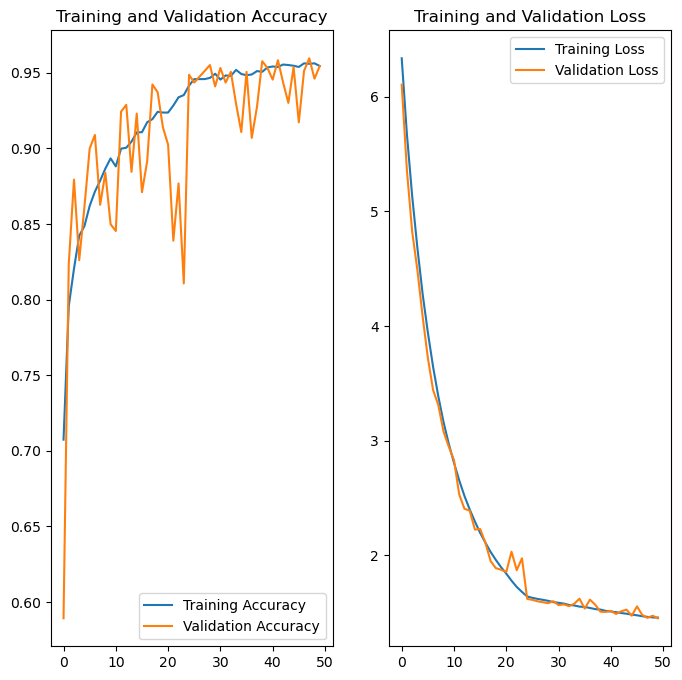

In [29]:
# 6. EVALUATE
# ==========================================================
print("\nFinal Evaluation:")
loss, accuracy = model.evaluate(val_ds)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

# Plotting
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss_vals = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss_vals, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [30]:
def check_image(image_path):

    img_height = 180
    img_width = 180

    # Load image
    img = tf.keras.utils.load_img(image_path)
    img = tf.keras.utils.img_to_array(img)

    # Resize
    img = tf.image.resize(img, [img_height, img_width])

    # Prepare for model
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, 0)   # IMPORTANT

    # Predict
    prediction = model.predict(img)
    score = prediction[0][0]

    if score < 0.5:
        print("Prediction: With Carbide :", score)
    else:
        print("Prediction: Without Carbide :", score)

In [31]:
# Run this to test
test_image_path = r'test images\natural banana\1201.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 67ms/step
Prediction: Without Carbide : 0.9678093


In [32]:
# Run this to test
test_image_path = r'test images\artificial banana\1481.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 13ms/step
Prediction: With Carbide : 0.027563777


In [33]:
# Run this to test
test_image_path = r'C:\Users\igles\MORTEAM13\test4.jpg'
check_image(test_image_path)

1/1 [==============================] - 0s 12ms/step
Prediction: Without Carbide : 0.9999999


In [34]:
# Run this to test
test_image_path = r"C:\Users\igles\Downloads\1234.jpg"
check_image(test_image_path)

1/1 [==============================] - 0s 17ms/step
Prediction: With Carbide : 6.184136e-11


In [35]:
# Save the entire model to a keras file
model.save('CNN_95.44%.keras')

# Optional: Save as .h5 if you prefer the older format
# model.save('pretrained_model.h5')

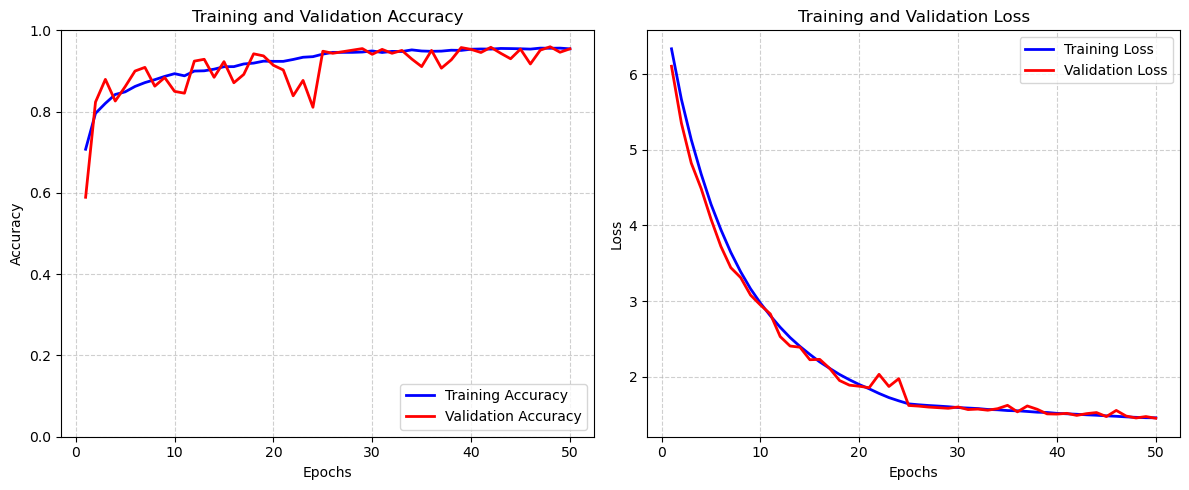

In [51]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)

ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='red', linewidth=2)

ax1.set_xlabel('Epochs') 
ax1.set_ylabel('Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.legend(loc='lower right') 
ax1.grid(True, linestyle='--', alpha=0.6) 
ax1.set_ylim([0, 1]) 

ax2.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
ax2.plot(epochs_range, val_loss, label='Validation Loss', color='red', linewidth=2)

ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('Training and Validation Loss')
ax2.legend(loc='upper right') 
ax2.grid(True, linestyle='--', alpha=0.6) 


plt.tight_layout()
plt.show()

98/98 [==============================] - 2s 17ms/step


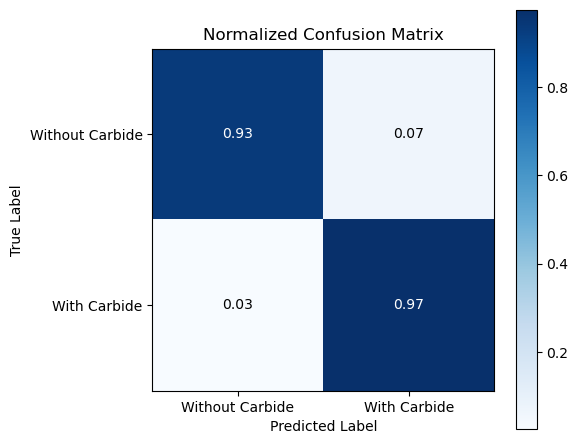

In [65]:

y_true_list = []
for images, labels in val_ds:
    y_true_list.append(labels)
    

y_true = np.concatenate(y_true_list, axis=0)

y_pred_probs = model.predict(val_ds)

y_pred = (y_pred_probs > 0.5).astype(int)


y_true = y_true.reshape(-1)
y_pred = y_pred.reshape(-1)


cm = tf.math.confusion_matrix(labels=y_true, predictions=y_pred).numpy()


row_sums = cm.sum(axis=1, keepdims=True)

row_sums[row_sums == 0] = 1 
cm_normalized = cm / row_sums


plt.figure(figsize=(6, 5))
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Normalized Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Without Carbide', 'With Carbide'])
plt.yticks(tick_marks, ['Without Carbide', 'With Carbide'])

thresh = cm_normalized.max() / 2.
for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        plt.text(j, i, format(cm_normalized[i, j], '.2f'),
                 ha="center", va="center",
                 color="white" if cm_normalized[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

98/98 [==============================] - 1s 13ms/step


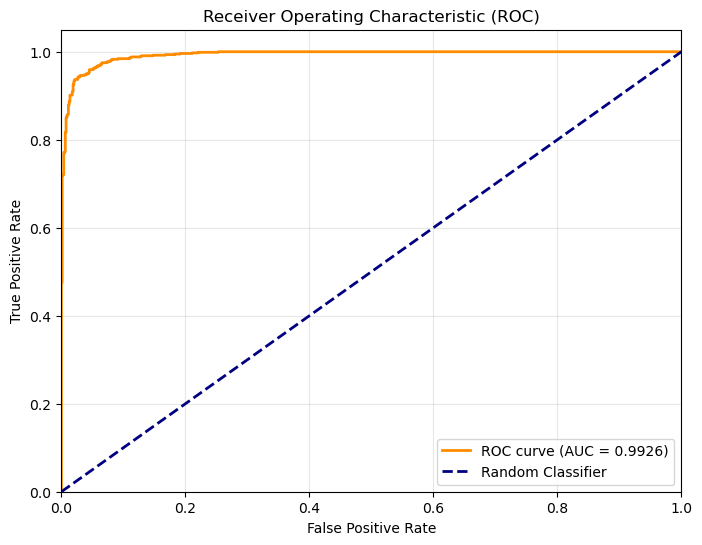

In [68]:
y_true_list = []
for images, labels in val_ds:
    y_true_list.append(labels)
y_true = np.concatenate(y_true_list, axis=0).flatten() 


y_pred_probs = model.predict(val_ds).flatten()


desc_score_indices = np.argsort(y_pred_probs)[::-1]
y_true_sorted = y_true[desc_score_indices]


tps = np.cumsum(y_true_sorted)
fps = np.cumsum(1 - y_true_sorted)

total_pos = tps[-1] if len(tps) > 0 else 1
total_neg = fps[-1] if len(fps) > 0 else 1

epsilon = 1e-10
tpr = tps / (total_pos + epsilon)
fpr = fps / (total_neg + epsilon)


tpr = np.insert(tpr, 0, 0)
fpr = np.insert(fpr, 0, 0)


auc_value = np.trapz(tpr, fpr)


plt.figure(figsize=(8, 6))


plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_value:.4f})')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()